## Data Cleaning Markdown
- Collect data from Hugging Face
- Subset for variables of interest
- Plot the variables of interest in different ways
- Inspect the data
- Check for NAs
- Clean

### PHASE 1: Data Cleaning

In [2]:
# Setup
from datasets import load_dataset
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import sys
import missingno as msno
from langdetect import detect, LangDetectException
sns.set_palette("Set3")


/Users/mattie/Desktop/Masters/Data Science/DataScience2026/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load data set for only the food products
ds = load_dataset("openfoodfacts/product-database", split="food")

Generating food split: 4495849 examples [01:02, 71421.30 examples/s] 
Generating beauty split: 62712 examples [00:01, 40534.36 examples/s]


In [4]:
# columns of interest
columns_of_interest = [
    "product_name",
    "brands",
    "nova_group",
    "nutriscore_score",
    "nutriscore_grade",
    "lang",
    "languages_tags",
    "ingredients_original_tags",
    "code"
]

# convert to df
df = ds.select_columns(columns_of_interest).to_pandas()

In [5]:
# create data directory if it doesn't exist
if not os.path.exists("../data"):
    os.makedirs("../data")
df.to_parquet('../data/raw_data.parquet') # keeps complex data types

In [6]:
# load raw data from parquet to keep complex data types  - run from here instead of above if you have already saved the raw data
df = pd.read_parquet('../data/raw_data.parquet')

In [7]:
# Inspect first few rows of the dataset
df.head()

,product_name,brands,nova_group,nutriscore_score,nutriscore_grade,lang,languages_tags,ingredients_original_tags,code
0,"[{'lang': 'main', 'text': 'Véritable pâte à ta...",Bovetti,NaN,25.0,e,fr,"[en:french, en:1]",None,0000101209159
1,"[{'lang': 'main', 'text': 'Chamomile Herbal Te...",Lagg's,1.0,NaN,unknown,en,"[en:english, en:1]",[en:camomile-flower],0000105000011
2,"[{'lang': 'main', 'text': 'Lagg's, herbal tea,...",Lagg's,1.0,NaN,unknown,en,"[en:english, en:1]",[en:peppermint],0000105000042
3,"[{'lang': 'main', 'text': 'Linden Flowers Tea'...",Lagg's,NaN,NaN,unknown,en,"[en:english, en:1]",[en:linden-flowers],0000105000059
4,"[{'lang': 'main', 'text': 'Herbal Tea, Hibiscu...",Lagg's,NaN,NaN,unknown,en,"[en:english, en:1]",[en:roselle-flower],0000105000073


In [8]:
# See rows and columns
df.shape

(4495849, 9)

In [9]:
# filter for only rows where language_tags which is a list has 'en:english' and en:1

print(df['languages_tags'].iloc[0])
print(type(df['languages_tags'].iloc[0]))
df.shape

# keep rows where language_tags contains BOTH 'en:english' and 'en:1'
df = df[df['languages_tags'].apply(
    lambda tags: isinstance(tags, np.ndarray) and 'en:english' in tags and 'en:1' in tags
)]

# keep rows where lang is 'en' just to be sure
df = df[df['lang'] == 'en'].copy()

print(df.shape)

['en:french' 'en:1']
<class 'numpy.ndarray'>
(1708922, 9)


In [10]:
print(type(df['product_name'].iloc[1]))

<class 'numpy.ndarray'>


In [11]:
# Extract product name from product name dictionary column
df['product_name_clean'] = df['product_name'].apply(
    lambda x: x[0]['text'] if isinstance(x, np.ndarray) and len(x) > 0 else None
)
df["product_name_clean"].head(20)

1                                  Chamomile Herbal Tea
2                        Lagg's, herbal tea, peppermint
3                                    Linden Flowers Tea
4                                  Herbal Tea, Hibiscus
5                                  Apple & Cinnamon Tea
6                                             Green Tea
7                                Shave Grass Herbal Tea
8                  Lagg's, herbal tea, chamomile * mint
9                                  Artichoke Herbal Tea
10                          Lagg's, dieter's herbal tea
11                        Lagg's, kidneytea, herbal tea
12                                            Bronchtea
13                                 100% Pure Canola Oil
15    Canola harvest, buttery spread, with flaxseed oil
16                                 Lithuanian Rye Bread
20                               Magic Stars Chocolates
21                               Magic Stars Chocolates
22              Mcvitie's, digestives cheesecake

In [12]:
# concatenate brand and product name to create a unique product ID - if brand is na then just use product name
df["product_ID"] = np.where(
    df["brands"].isna(),
    df["product_name_clean"].astype(str),
    df["brands"] + "_" + df["product_name_clean"].astype(str)
)

# make sure no products duplicated by "code" (barcode) - also unique product ID
if df["code"].nunique() != len(df):
    print("Warning: code column has duplicates.")

# for code duplicates keep the instance with the most data (least missing values)
df["missing_values"] = df.isna().sum(axis=1)
df = df.sort_values("missing_values").drop_duplicates(subset="code", keep="first").drop(columns="missing_values")

# double check for duplicates after dropping
if df["code"].nunique() != len(df):
    print("Warning: code column has duplicates.")
else:
    print("No duplicates in code column.")

No duplicates in code column.


In [13]:
df.shape

(1708917, 11)

### PHASE 2: Data Inspection & Plotting

In [14]:
# count na in each column
na_count = df.isna().sum()

# get percentage of missing values in each column
na_percent = df.isna().mean()*100

# combine into a dataframe
na_df = pd.DataFrame({"na_count": na_count, "na_percent": na_percent})
print(na_df)

                           na_count  na_percent
product_name                      0    0.000000
brands                       597416   34.958749
nova_group                  1244570   72.827996
nutriscore_score            1255683   73.478291
nutriscore_grade              36361    2.127722
lang                              0    0.000000
languages_tags                    0    0.000000
ingredients_original_tags   1160573   67.912778
code                              0    0.000000
product_name_clean           145688    8.525165
product_ID                   145688    8.525165


OBS: We have quite a lot of data without a nova group or a numerical nutriscore score. But many more do have a nutrigrade. So we should probably use the grade instead of the score - I will continue by using the nutrigrade.

#### Create filtered df where there are ingredients and nutriscores

In [15]:
# filter for rows with a nutriscore_grade and ingredients_original_tags
df_filtered = df[df["nutriscore_grade"].notna() & df["ingredients_original_tags"].notna()].copy()

df_filtered.shape

(548334, 11)

#### Inspect df with novas for NA inspection

In [16]:
# create df where nova is present
with_nova = df_filtered[df_filtered["nova_group"].notna()].copy()

with_nova.shape

(456653, 11)

In [17]:
# see how many products fall into each nova score for the with nova df
print(with_nova["nova_group"].value_counts())

nova_group
4.0    326124
3.0     77930
1.0     45275
2.0      7324
Name: count, dtype: int64


In [18]:
# see how many products fall into each nutriscore grade for the missing nova df
print(with_nova["nutriscore_grade"].value_counts())

nutriscore_grade
e                 109076
unknown           100791
d                  84785
c                  67034
a                  51751
b                  33683
not-applicable      9533
Name: count, dtype: int64


In [19]:
# exclude all rows with nutriscore_grade == "unknown" and "not-applicable" from the df_filtered data frame
df_filtered = df_filtered[~df_filtered['nutriscore_grade'].isin(['unknown', 'not-applicable'])]

#Checking if they're gone
print(df_filtered["nutriscore_grade"].value_counts())

nutriscore_grade
e    124235
d     91322
c     75112
a     58514
b     43666
Name: count, dtype: int64


##### Inspect ingredients list and remove NAs

In [20]:
# Parse ingredients_original_tags into actual lists
def get_tags(raw):
    if raw is None:
        return []
    if isinstance(raw, np.ndarray):
        return raw.tolist()
    if isinstance(raw, list):
        return raw
    return []

df_filtered['ingredients_parsed'] = df_filtered['ingredients_original_tags'].apply(get_tags)

# combined tag-level filter in one pass:
# 1. keep only en: prefix
# 2. keep E numbers (en:e471) and drop purely numeric tags (en:1)
# 3. keep only Latin alphabet tags
import unicodedata

def is_valid_tag(tag):
    if not tag.startswith('en:'):
        return False
    value = re.sub(r'^[a-z]{2}:', '', tag)
    
    # keep E numbers like e471, e150a
    if re.match(r'^e\d+', value):
        return True
    
    # remove ANY tag containing a digit that isn't an E number
    if re.search(r'\d', value):
        return False
    
    # drop non-Latin characters
    return all(unicodedata.category(c) != 'Lo' for c in tag)

df_filtered['ingredients_parsed'] = df_filtered['ingredients_parsed'].apply(
    lambda tags: [tag for tag in tags if is_valid_tag(tag)]
)

# single empty list removal
before = df_filtered.shape[0]
df_filtered = df_filtered[df_filtered['ingredients_parsed'].apply(lambda x: len(x) > 0)]
after = df_filtered.shape[0]
print(f"Removed {before - after} rows with no valid ingredients")
print(f"Remaining rows: {after}")

# parse to clean text
def parse_ingredient(tag):
    return re.sub(r'^[a-z]{2}:', '', tag).replace('-', ' ')

df_filtered['ingredients_clean'] = df_filtered['ingredients_parsed'].apply(
    lambda tags: [parse_ingredient(t) for t in tags]
)

# remove undefined/unknown
mask = df_filtered['ingredients_parsed'].apply(
    lambda tags: not any('undefined' in str(tag).lower() or 'unknown' in str(tag).lower() for tag in tags)
)
before = df_filtered.shape[0]
df_filtered = df_filtered[mask]
after = df_filtered.shape[0]
print(f"Removed {before - after} rows with 'undefined' or 'unknown' ingredients")
print(f"Remaining rows: {after}")

Removed 738 rows with no valid ingredients
Remaining rows: 392111
Removed 34737 rows with 'undefined' or 'unknown' ingredients
Remaining rows: 357374


In [ ]:
def is_english_ingredients(ingredient_list):
    if not ingredient_list:
        return False
    # join ingredients into one string for detection
    text = ' '.join(ingredient_list)
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

before = df_filtered.shape[0]
df_filtered = df_filtered[df_filtered['ingredients_clean'].apply(is_english_ingredients)]
after = df_filtered.shape[0]

print(f"Removed {before - after} rows with non-English ingredients")
print(f"Remaining rows: {after}")

#### Inspect df without novas

In [ ]:
# see how many rows of the filtered dataset have a nova group
missing_nova = df_filtered[df_filtered["nova_group"].isna()].copy()

missing_nova.shape

(6381, 13)

In [ ]:
# percentage of df_filtered that doesn't have a nova
percent_missing_nova = (missing_nova.shape[0] / df_filtered.shape[0]) * 100
print(f"Percentage of df_filtered without nova_group: {percent_missing_nova:.2f}%")

Percentage of df_filtered without nova_group: 2.34%


In [ ]:
# see how many products fall into each nutriscore grade for the missing nova df
print(missing_nova["nutriscore_grade"].value_counts())

nutriscore_grade
a    2393
b    1256
c     983
d     890
e     859
Name: count, dtype: int64


In [ ]:
# create plots folder
if not os.path.exists("../plots"):
    os.makedirs("../plots")

In [ ]:
print(f"df_filtered shape going into plots: {df_filtered.shape}")
print(df_filtered["nova_group"].value_counts())
print(df_filtered["nutriscore_grade"].value_counts())

df_filtered shape going into plots: (272461, 13)
nova_group
4.0    196881
3.0     49068
1.0     18185
2.0      1946
Name: count, dtype: int64
nutriscore_grade
e    88127
d    67499
c    54679
a    35571
b    26585
Name: count, dtype: int64


In [ ]:
print(f"Raw data: {df.shape[0]} rows")
print(f"After all filtering: {df_filtered.shape[0]} rows")
print(f"Removed: {df.shape[0] - df_filtered.shape[0]} rows total")

Raw data: 1697754 rows
After all filtering: 272461 rows
Removed: 1425293 rows total


### Plotting

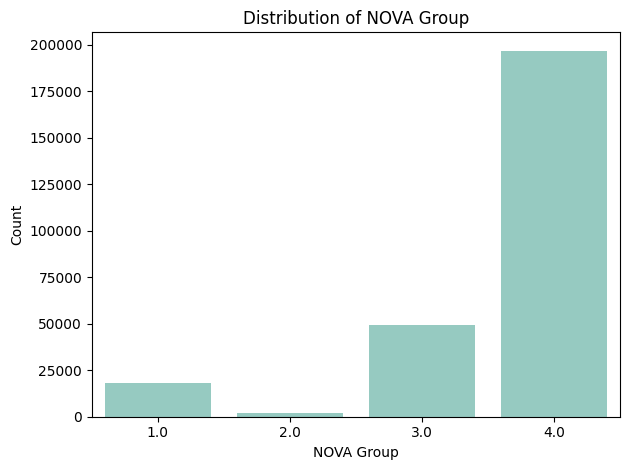

In [ ]:
# Plotting the distribution of nova_group 
sns.countplot(data=df_filtered, x='nova_group', order=sorted(df_filtered['nova_group'].dropna().unique()))
plt.title('Distribution of NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../plots/nova_group_distribution.png', dpi=150)
plt.show()

/var/folders/8q/0xtf9l0d2wd2qw2lng8ncfvm0000gp/T/ipykernel_5338/2805636987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='nova_group', y='nutriscore_score',


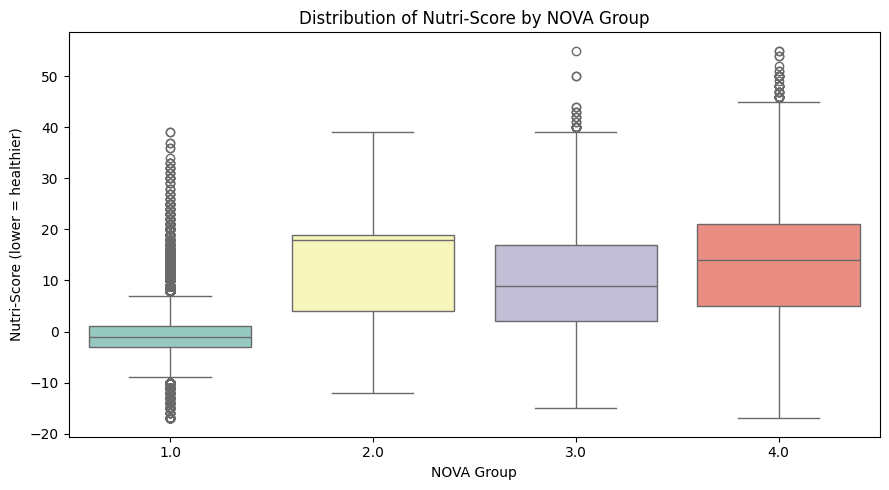

In [ ]:
# plotting distribution of nutriscore_score by nova_group
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_filtered, x='nova_group', y='nutriscore_score', 
            order=sorted(df_filtered['nova_group'].dropna().unique()),
            palette='Set3')
plt.title('Distribution of Nutri-Score by NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Nutri-Score (lower = healthier)')
plt.tight_layout()
plt.savefig('../plots/nutriscore_by_nova.png', dpi=150)
plt.show()

In [ ]:
# plot nutrigrade against nova group for with original nova df
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_filtered,
    x='nutriscore_grade',
    hue='nova_group',
    order=['a', 'b', 'c', 'd', 'e'],
    hue_order=[1, 2, 3, 4]
)
plt.title('Nutri-Score Grade vs NOVA Group')
plt.xlabel('Nutri-Score Grade')
plt.ylabel('Count')
plt.legend(title='NOVA Group')
plt.tight_layout()
plt.savefig(f'{output_dir}/nutrigrade_vs_nova.png', dpi=150)
plt.show()

NameError: name 'plt' is not defined

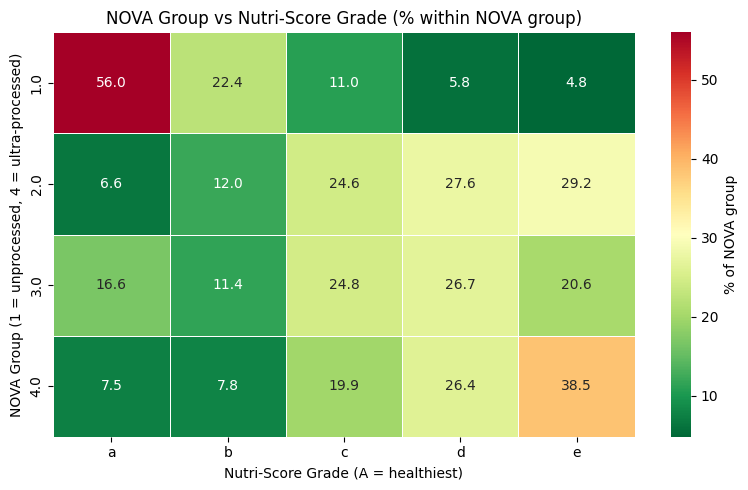

In [ ]:
# Build the contingency table
heatmap_data = df_filtered.groupby(['nova_group', 'nutriscore_grade']).size().unstack(fill_value=0)

# Order the axes meaningfully
nova_order = sorted(heatmap_data.index)
nutriscore_order = ['a', 'b', 'c', 'd', 'e']
heatmap_data = heatmap_data.reindex(index=nova_order, columns=nutriscore_order)

# Normalize by row so each NOVA group sums to 100%
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '% of NOVA group'})
plt.title('NOVA Group vs Nutri-Score Grade (% within NOVA group)')
plt.xlabel('Nutri-Score Grade (A = healthiest)')
plt.ylabel('NOVA Group (1 = unprocessed, 4 = ultra-processed)')
plt.tight_layout()
plt.savefig('../plots/nova_nutriscore_heatmap.png', dpi=150)
plt.show()

notes on plot above: 

- The expected pattern (processing = unhealthy):

NOVA 1 (unprocessed): 56% score A — most unprocessed foods are nutritionally good. This makes sense.

NOVA 4 (ultra-processed): 38.5% score E — a big chunk of ultra-processed foods score poorly. Also expected.


- The discordance:

NOVA 4 but grade A or B: 7.5% + 7.8% = 15.3% of ultra-processed foods still score well nutritionally. These are things like diet sodas, protein bars, or fortified cereals — heavily processed but engineered to hit good nutrient scores.

NOVA 2 but grade E: 29.2% — this is the biggest surprise. Lightly processed foods scoring very poorly. Think things like salted butter, cured meats, or full-fat cheese — minimally processed but high in fat/salt/sugar.


- The headline takeaway:

Nutri-Score and NOVA group measure different things. A food can be ultra-processed yet score A, or barely processed yet score E. The two systems are complementary, not redundant — which is exactly why both matter

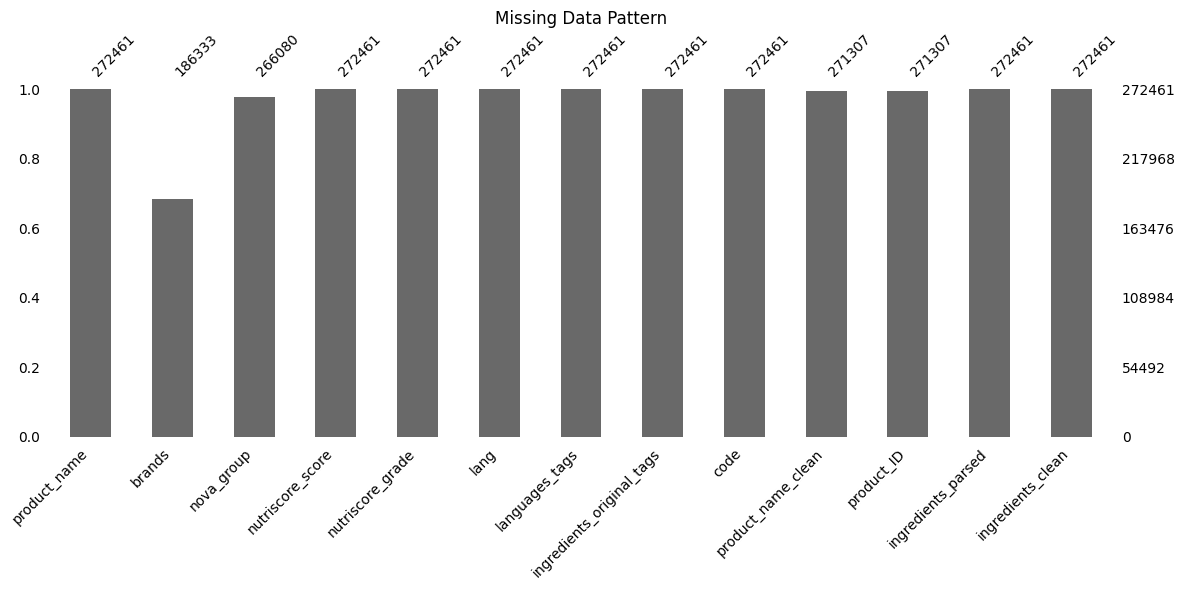

In [ ]:
plt.figure()
#msno.matrix(df, figsize=(12, 6), fontsize=10, sparkline=False)
msno.bar(df_filtered, figsize=(12, 6), fontsize=10)
plt.title('Missing Data Pattern')
plt.tight_layout()
plt.savefig('../plots/missing_data_pattern.png', dpi=150)
plt.show()

notes on plot above:

- Bar height = proportion of non-missing values (1.0 = fully complete, 0.0 = all missing)

- The numbers on top = actual count of non-missing rows

In [ ]:
# Save dataset to local repo but large dataset saved to huggingface
df_filtered.to_parquet("../data/cleaned_data.parquet", index=False)


# link to hugging face for reference
# ds2 = load_dataset("MattiWhen/filtered_openfood", token = token) # token in txt file